## Imports

In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import datetime
import einops
from torch import nn
import torch as t
from typing import List
from jaxtyping import Float, Int
from tyche.inductive_bias import *
from tyche.MLP_metrics import run_train_and_estimator

import itertools
import plotly.graph_objs as go  # Import the graph objects from Plotly
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from tqdm.notebook import tqdm
import pandas as pd
from tyche.estimator import VolumeConfig, VolumeEstimator

In [24]:
device = t.device("cuda:7" if t.cuda.is_available() else "cpu")
t.set_default_device(device)

In [25]:
import os
import torch as t
import einops
import plotly.graph_objects as go


def plot_indicator_table(model, params, save=False):
    device = next(model.parameters()).device
    N = params.N
    group_set = [[i, j, (i + j) % N] for i in range(N) for j in range(N)]
    inputs = t.tensor([g[:2] for g in group_set], dtype=t.long).to(device)

    with t.no_grad():
        model.eval()
        logits = model(inputs)  # shape N^2 x N
        max_prob_entry = t.argmax(logits, dim=-1)  # shape N^2

    output_matrix = einops.rearrange(max_prob_entry, "(n m) -> n m", n=N)  # shape N x N
    hover_labels = [[f"{output_matrix[j][i]}" for i in range(N)] for j in range(N)]
    row_labels = [str(g) for g in range(N)]
    col_labels = row_labels

    # Generate N different colors for the heatmap
    import plotly.colors as pc

    # Using a colorscale that works well for categorical data
    if N <= 10:
        # For small N, use distinct colors from the Plotly qualitative colorscales
        colors = pc.qualitative.Plotly[:N]
    else:
        # For larger N, generate a continuous colorscale with N distinct colors
        colorscale = pc.sequential.Viridis
        colors = [pc.sample_colorscale(colorscale, i / (N - 1))[0] for i in range(N)]

    # Create the colorscale with proper scaling between 0 and 1
    custom_colorscale = []
    for i in range(N):
        # Lower bound for this color
        custom_colorscale.append([i / N, colors[i]])
        # Upper bound for this color (except for the last color)
        if i < N - 1:
            custom_colorscale.append([(i + 1) / N, colors[i]])

    fig = go.Figure(
        data=go.Heatmap(
            z=output_matrix.tolist(),
            showscale=False,
            colorscale=custom_colorscale,
            x=col_labels,
            y=row_labels,
            zmin=0,
            zmax=N - 1,
            customdata=hover_labels,
            hovertemplate="x=%{x}<br>"
            + "y=%{y}<br>"
            + "z=%{customdata}<extra></extra>",
        ),
    )

    fig.update_layout(
        title=f"Final run",
        xaxis={
            "showgrid": True,
            "side": "top",
            "ticks": "outside",
            "tickmode": "array",
            "tickvals": [i for i in range(N)],
            "ticktext": row_labels,
        },
        yaxis={
            "showgrid": True,
            # "autorange": "reversed",
            "side": "left",
            "ticks": "outside",
            "tickmode": "array",
            "tickvals": [i for i in range(N)],
            "ticktext": col_labels,
        },
        height=900,
        width=900,
    )

    if save:
        # Create plots directory if it doesn't exist
        if not os.path.exists("plots"):
            os.mkdir("plots")
        fig.write_html("./plots/plot_final.html")

    return fig

## Evaluating hyperparameter search

In [8]:
WEIGHT_MODES = ["uniform", "xavier_uniform", "normal", "xavier_normal", "constant"]

In [9]:
path = "/home/louis/shared_database.parquet"
df = pd.read_parquet(path)
WEIGHT_MODES = ["none"]

<string>:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


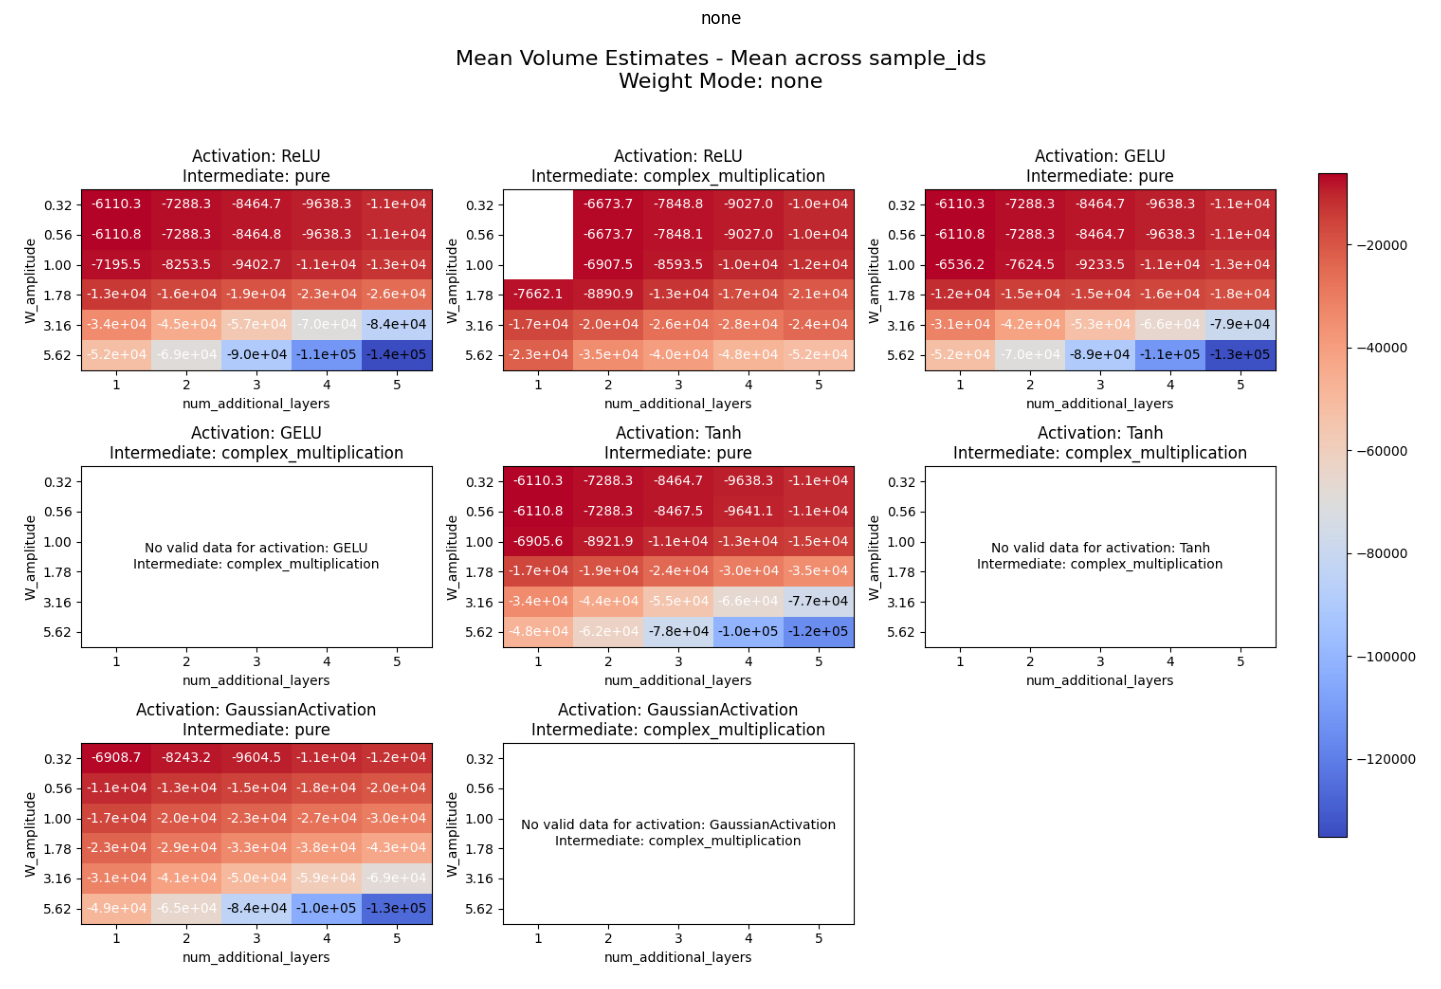

In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import io
from PIL import Image
import numpy as np

# Assuming df and WEIGHT_MODES are defined

num_weight_modes = len(WEIGHT_MODES)
num_activations = 5  # Assuming generate_heatmaps produces a plot with 5 heatmaps

# Determine the layout of the combined image grid
num_rows = num_weight_modes
num_cols = 1  # You can adjust this for a different arrangement

# Create the combined figure
fig_combined = plt.figure(figsize=(15 * num_cols, 10 * num_rows))
gs = gridspec.GridSpec(num_rows, num_cols)

for i, weight_mode in enumerate(WEIGHT_MODES):
    # Call generate_heatmaps to create the plot
    fig_individual = generate_heatmaps(
        df=df,
        weight_mode=weight_mode,
        stat_type="mean",
        volume_stat="mean",
        cmap="coolwarm",
    )

    # Save the individual figure to a BytesIO object (in-memory)
    buf = io.BytesIO()
    fig_individual.savefig(buf, format="png")
    buf.seek(0)
    img = Image.open(buf)
    img_array = np.array(img)
    plt.close(fig_individual)  # Close the individual figure

    # Add the image to the combined figure
    row = i // num_cols
    col = i % num_cols
    ax = fig_combined.add_subplot(gs[row, col])
    ax.imshow(img_array)
    ax.axis("off")  # Turn off axis labels and ticks
    ax.set_title(WEIGHT_MODES[i])

plt.tight_layout()
plt.show()

In [10]:
df["intermediate"].unique()

array(['pure', 'complex_multiplication'], dtype=object)

In [11]:
df_pure = df[df["intermediate"] == "pure"].copy()
df_complex = df[df["intermediate"] == "complex_multiplication"].copy()

In [19]:
df_pure["intermediate"].unique()

array(['pure'], dtype=object)

In [35]:
np.arange(-1, 2, 1)

array([-1,  0,  1])

/home/louis/tyche/src/tyche/inductive_bias_viz.py:351: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])  # Make room for colorbar and title


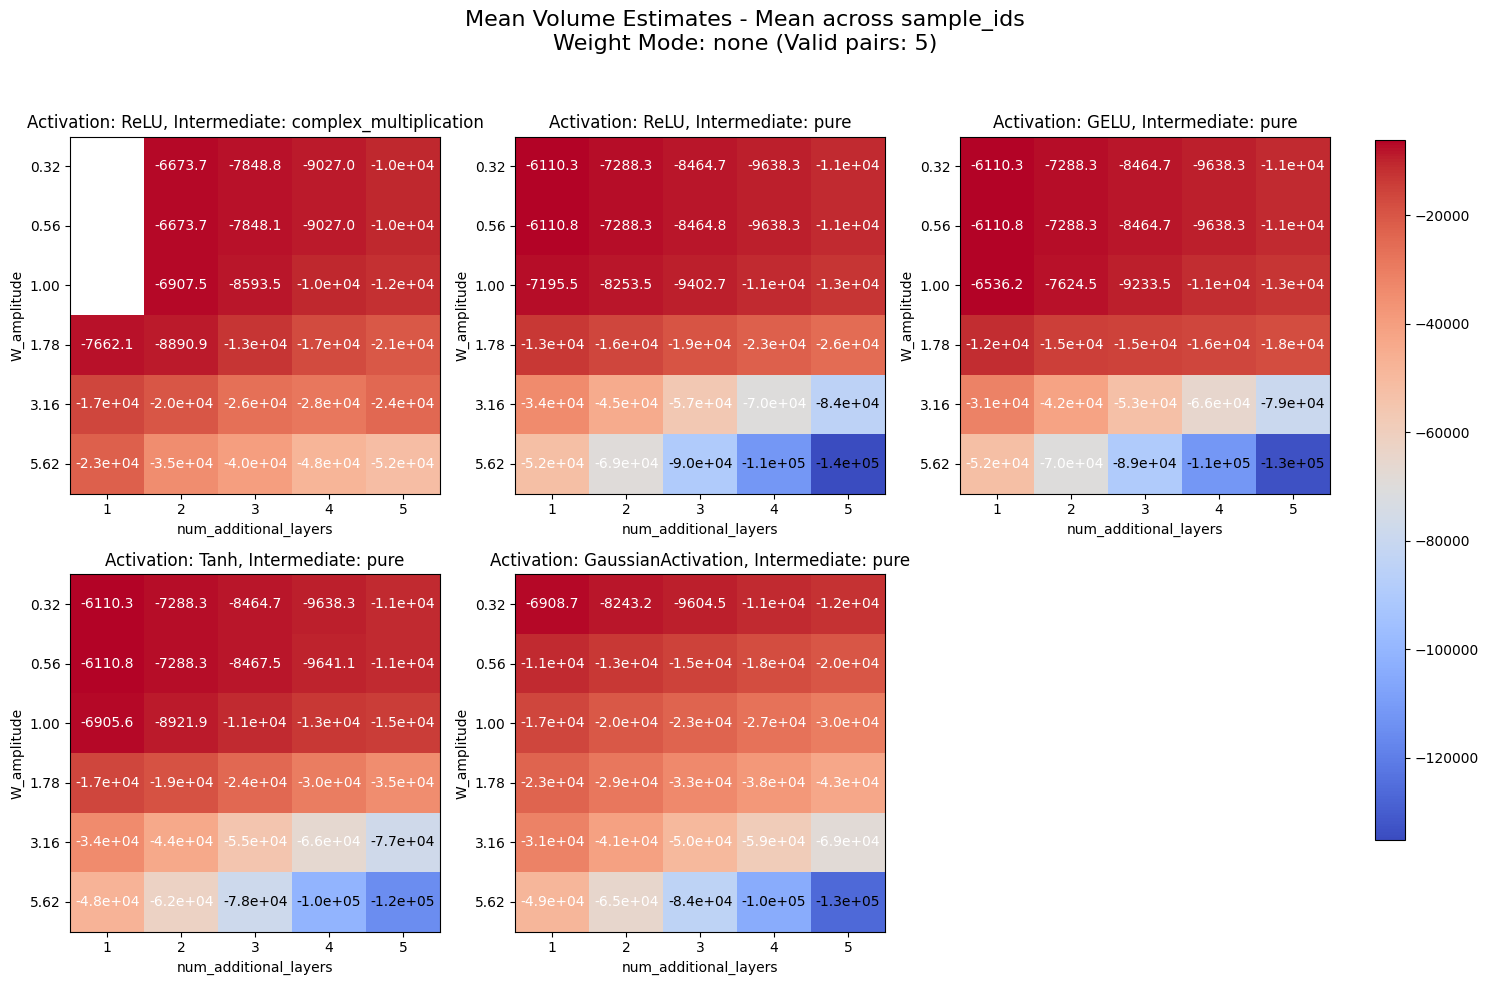

In [72]:
from tyche.inductive_bias_viz import generate_heatmaps


figures = generate_heatmaps(
    df=df,
    weight_mode="none",
    stat_type="mean",
    volume_stat="mean",
    figsize=(15, 10),
    cmap="coolwarm",
)
#

In [50]:
mask = (
    (df["activation"] == "ReLU")
    & (df["num_additional_layers"] == 2)
    & (df["W_amplitude"] == 1)
)

filtered_df = df[mask]

In [39]:
mlp_config = MLPConfig(
    N=53,
    embed_dimension=36,
    linear_dimension=48,
    dimensions=48,
    train_data_size=53**2,
    training_epochs=0,
    eval_interval=1000,
    weight_decay=2e-4,
)

config_dict = {
    "activation": t.nn.ReLU(),
    "num_additional_layers": 1,
    "W_amplitude": 0.32,
    "weight_mode": "none",
    "seed": 1,
}

mlp_config.update(**config_dict)

In [78]:
from tyche.MLP_metrics import run_train_and_estimator


run_train_and_estimator(mlp_config, gpu_id=7)

0it [00:00, ?it/s]


[{'activation': 'ReLU',
  'N': 53,
  'embed_dimension': 36,
  'linear_dimension': 48,
  'intermediate': 'pure',
  'embedding_tied': False,
  'unembedding_tied': False,
  'bias_unembed': False,
  'num_additional_layers': 1,
  'dimensions': 48,
  'bias_layer': False,
  'W_amplitude': 0.32,
  'weight_mode': 'none',
  'device': 'cuda:7',
  'b_amplitude': 0.0,
  'seed': 1,
  'save_model': False,
  'training_epochs': 0,
  'lr': 0.001,
  'weight_decay': 0.0002,
  'train_data_size': 2809,
  'eval_interval': 1000,
  'test_loss': 3.9702935218811035,
  'test_accuracy': 0.01886792480945587,
  'train_loss': 3.970292091369629,
  'train_accuracy': 0.01886792480945587,
  'volume_estimates': None,
  'epoch': 0}]

In [20]:
mask = (df["activation"] == "ReLU") & (df["num_additional_layers"] == 1)

filtered_df = df[mask]
filtered_df

,activation,N,embed_dimension,linear_dimension,intermediate,embedding_tied,unembedding_tied,bias_unembed,num_additional_layers,dimensions,...,lr,weight_decay,train_data_size,eval_interval,test_loss,test_accuracy,train_loss,train_accuracy,volume_estimates,epoch
74,ReLU,53,36,48,pure,False,False,False,1,48,...,0.001,0.0002,2809,1000,3.970409,0.018868,3.970409,0.018868,None,0
78,ReLU,53,36,48,pure,False,False,False,1,48,...,0.001,0.0002,2809,1000,3.970293,0.019580,3.970293,0.019580,None,0
100,ReLU,53,36,48,pure,False,False,False,1,48,...,0.001,0.0002,2809,1000,3.970406,0.019580,3.970406,0.019580,None,0
133,ReLU,53,36,48,pure,False,False,False,1,48,...,0.001,0.0002,2809,1000,21.911900,0.019580,21.911900,0.019580,"[-52149.92, -53844.766, -51139.617, -49765.242...",0
140,ReLU,53,36,48,pure,False,False,False,1,48,...,0.001,0.0002,2809,1000,25.141426,0.018868,25.141422,0.018868,"[-52251.05, -52252.547, -49032.035, -51241.625...",0
151,ReLU,53,36,48,pure,False,False,False,1,48,...,0.001,0.0002,2809,1000,3.970279,0.018868,3.970278,0.018868,None,0
162,ReLU,53,36,48,pure,False,False,False,1,48,...,0.001,0.0002,2809,1000,3.970293,0.018868,3.970293,0.018868,None,0
174,ReLU,53,36,48,pure,False,False,False,1,48,...,0.001,0.0002,2809,1000,4.490099,0.018868,4.490098,0.018868,"[-33172.863, -24439.262, -36267.668, -24452.52...",0
215,ReLU,53,36,48,pure,False,False,False,1,48,...,0.001,0.0002,2809,1000,3.970299,0.019580,3.970299,0.019580,None,0
227,ReLU,53,36,48,pure,False,False,False,1,48,...,0.001,0.0002,2809,1000,3.975936,0.019580,3.975936,0.019580,"[-12408.7295, -11018.66, -10977.401, -10946.07...",0


/tmp/ipykernel_212760/1279933447.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


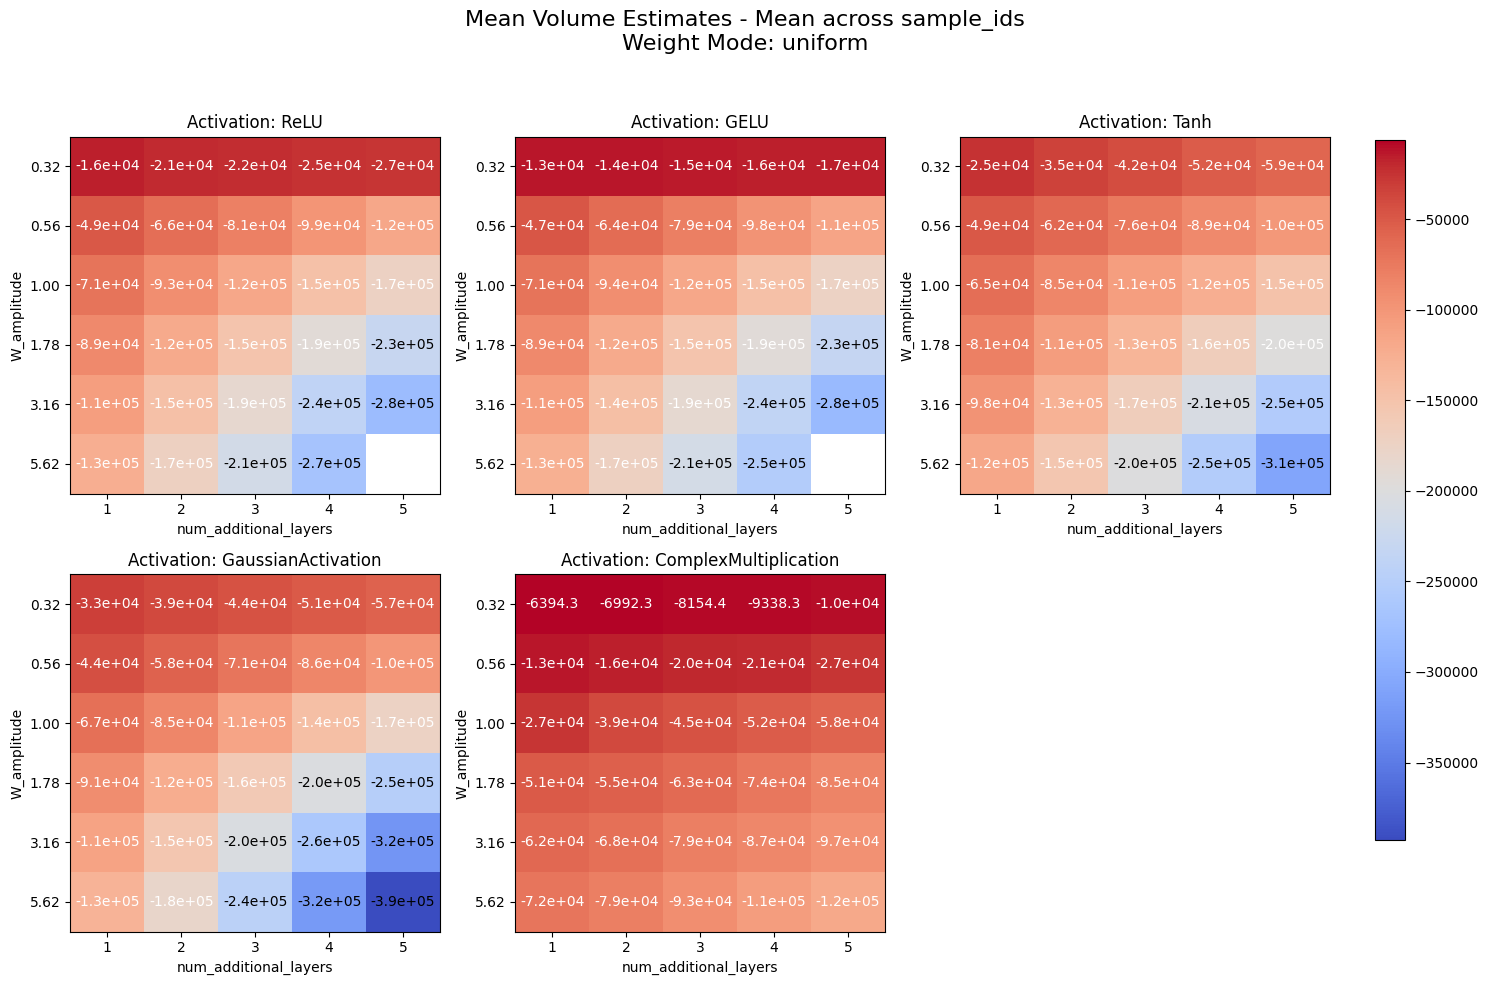

/tmp/ipykernel_212760/1279933447.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


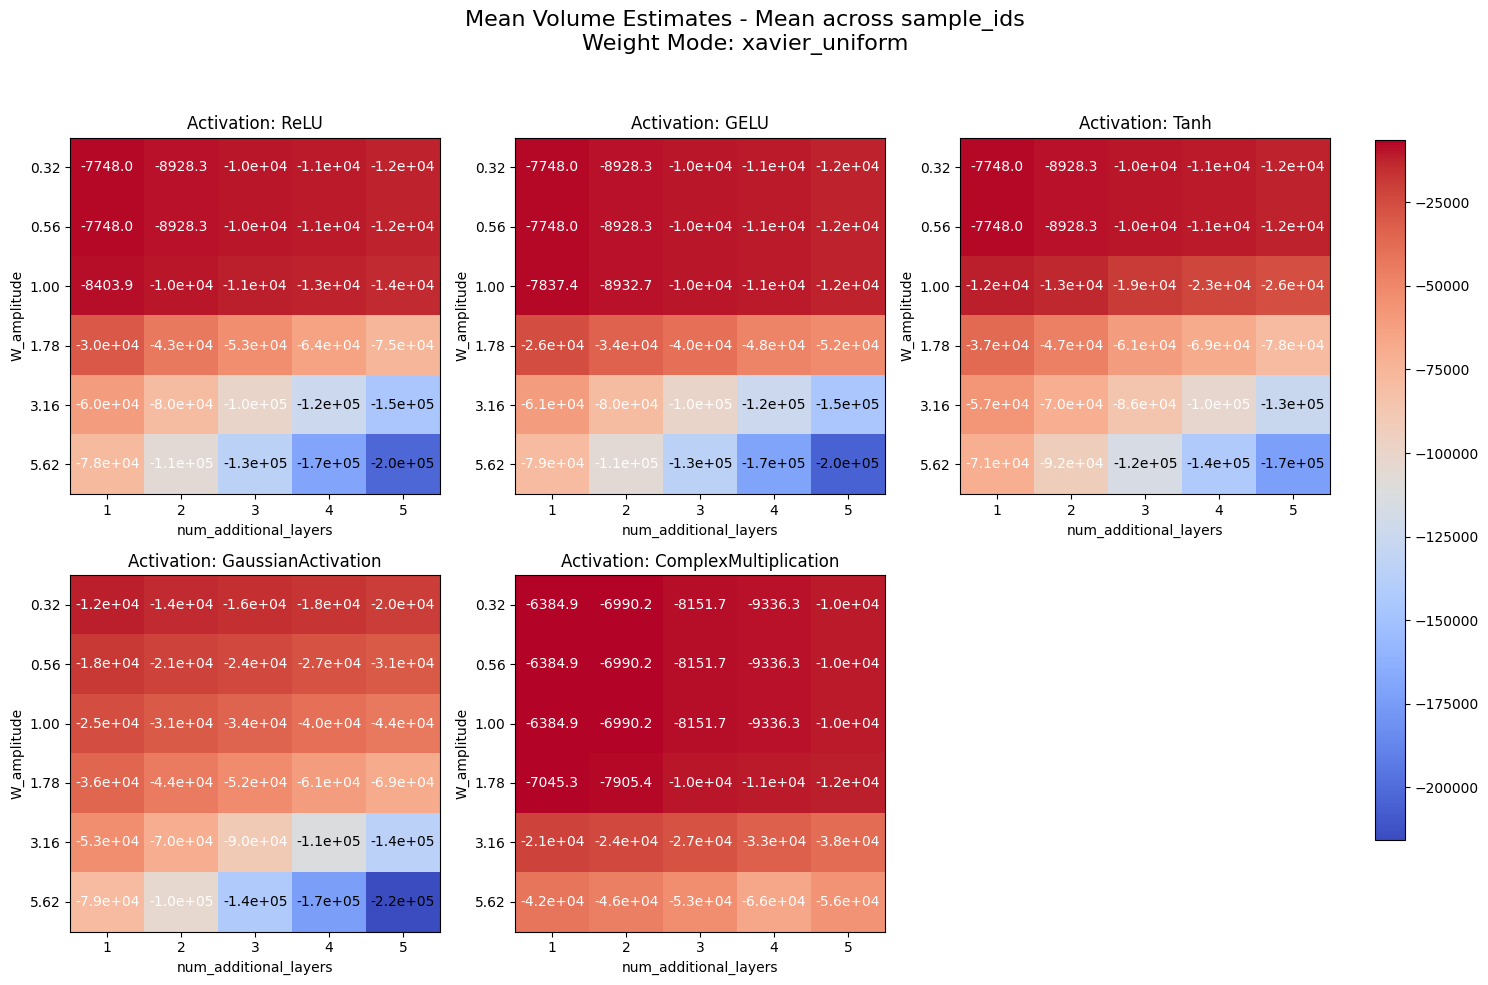

/tmp/ipykernel_212760/1279933447.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


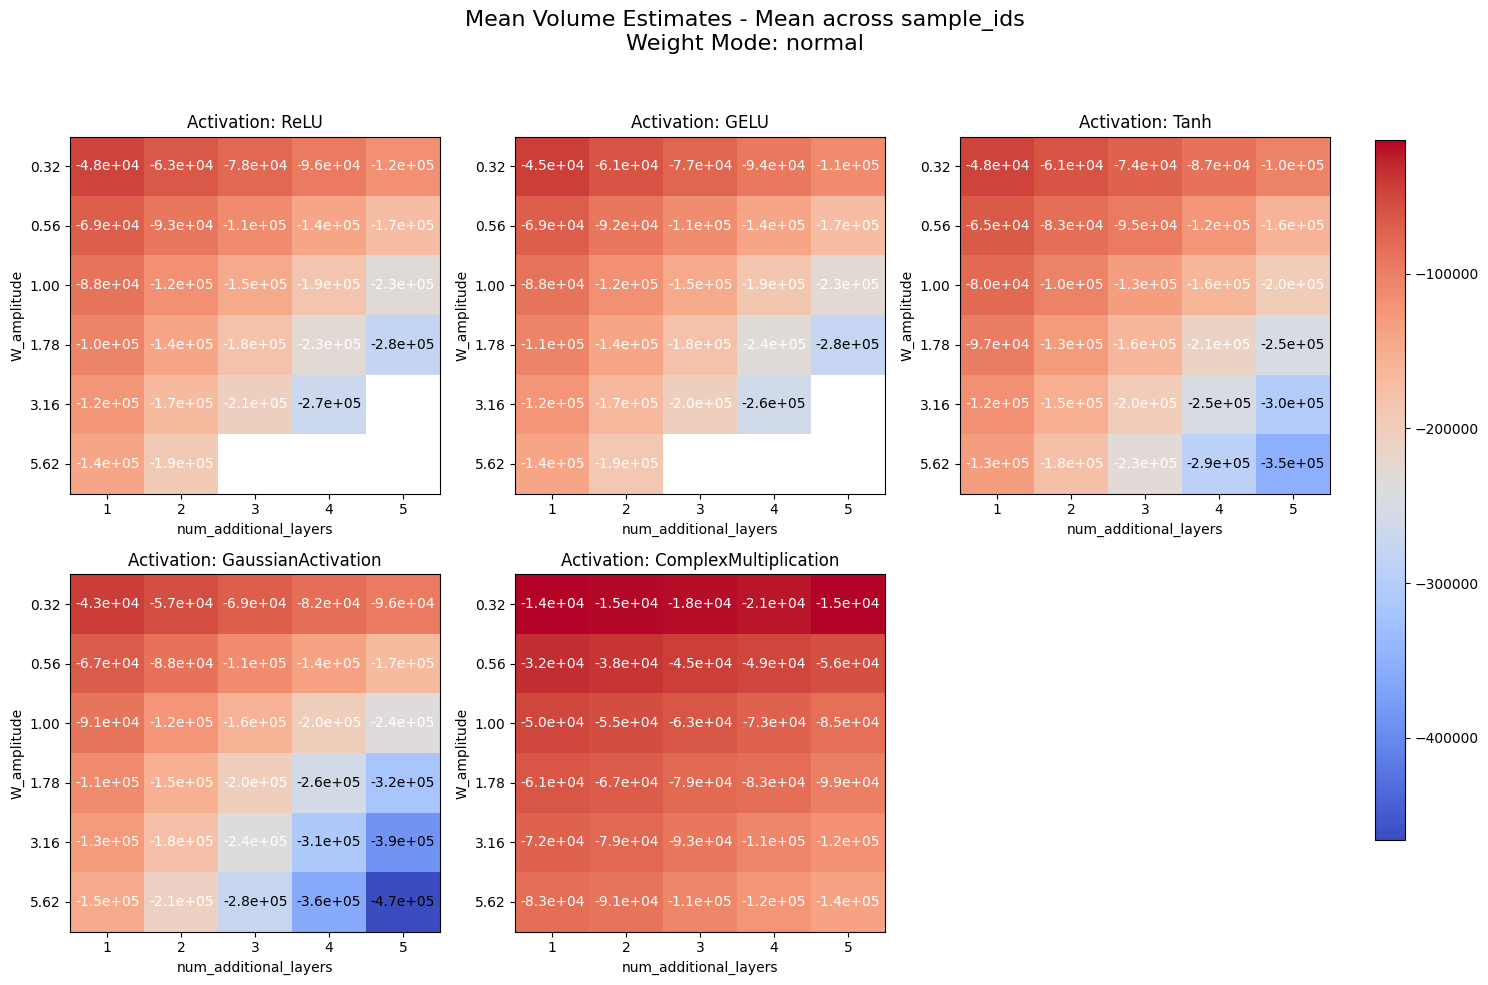

/tmp/ipykernel_212760/1279933447.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


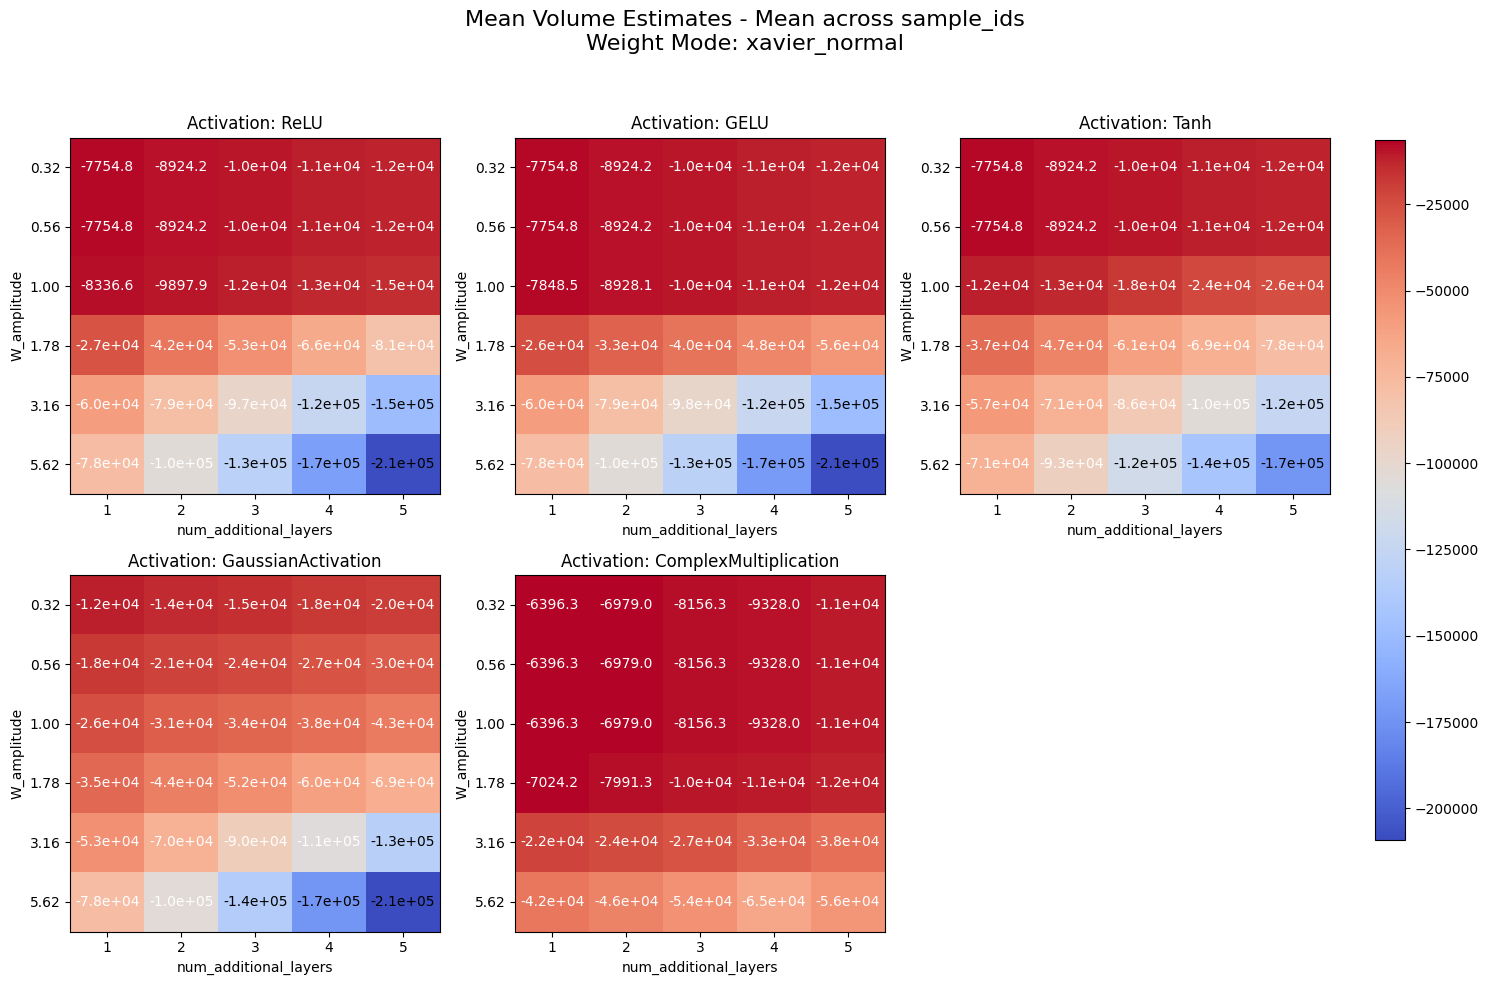

/tmp/ipykernel_212760/1279933447.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


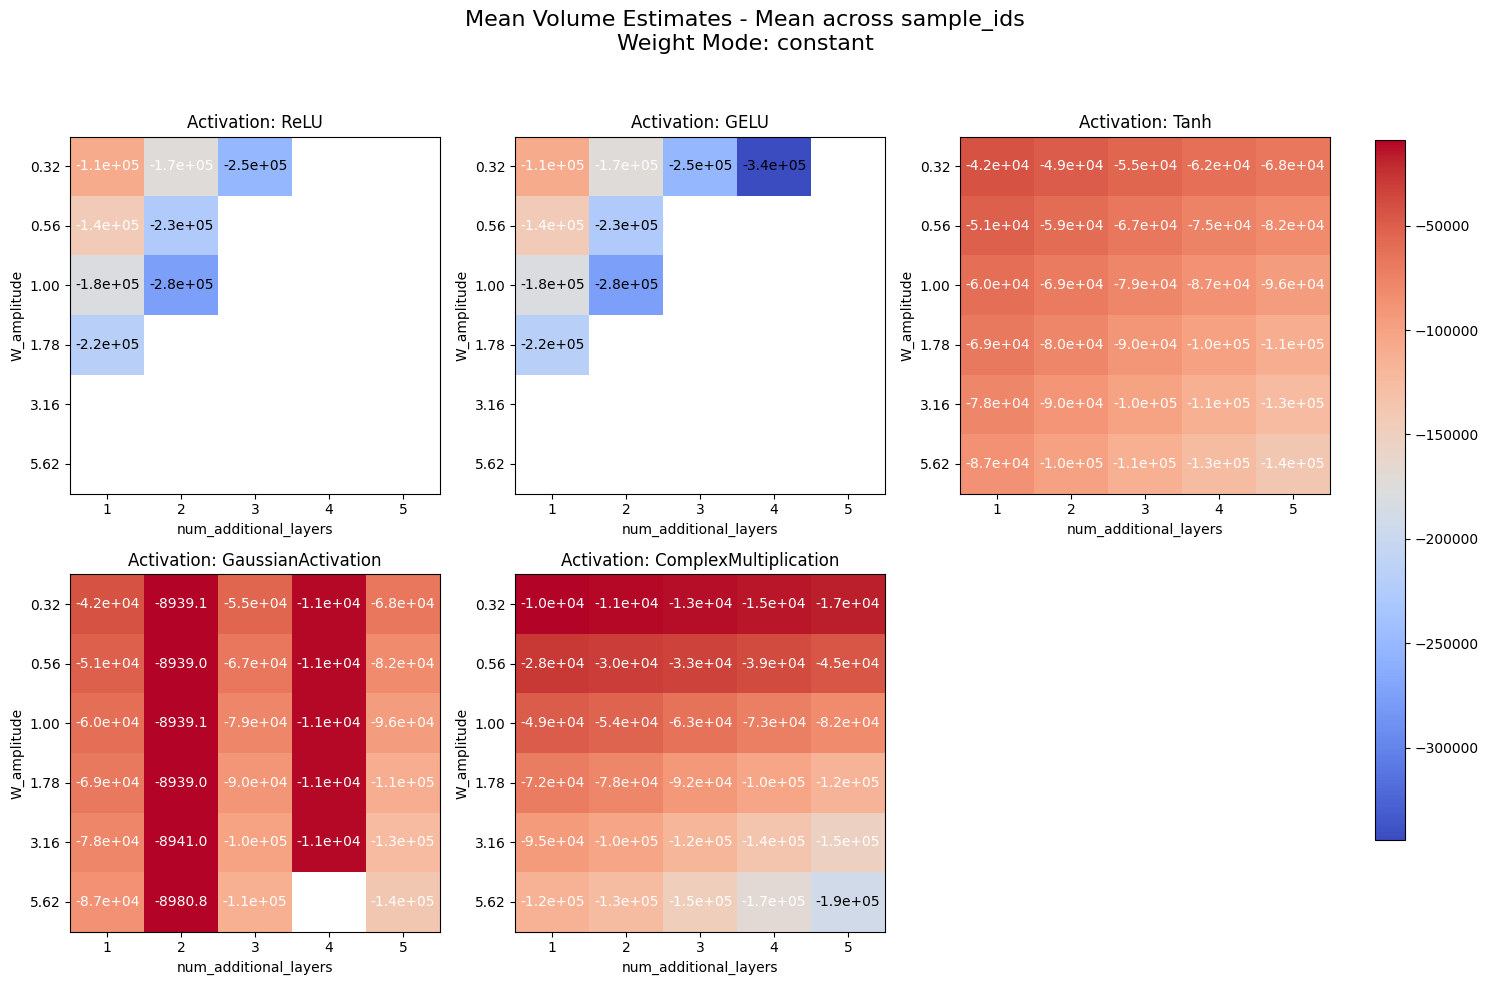

In [49]:
for weight_mode in WEIGHT_MODES:
    fig1 = generate_heatmaps(
        df,
        weight_mode=weight_mode,
        stat_type="mean",
        volume_stat="mean",
        cmap="coolwarm",
    )
    plt.show()

## training attempt

In [69]:
params = MLPConfig(
    activation=t.nn.ReLU(),
    N=53,
    embed_dimension=36,
    linear_dimension=48,
    intermediate="pure",
    embedding_tied=False,
    unembedding_tied=False,
    bias_unembed=False,
    num_additional_layers=1,
    dimensions=(48),
    bias_layer=False,
    W_amplitude=1,
    weight_mode="constant",
    device=device,
    b_amplitude=0.0,
    train_data_size=1600,
    training_epochs=10000,
    eval_interval=1000,
    weight_decay=2e-4,
)

model = MLP_VARIANTS(params)
model.initialize_weights()

In [71]:
results = run_train_and_estimator(custom_config=params, gpu_id=7)
a = [result["test_loss"] for result in results]
a

100%|██████████| 10000/10000 [00:27<00:00, 361.31it/s]


[3.970294952392578,
 15.21653938293457,
 3.981602430343628,
 3.9819512367248535,
 3.9816091060638428,
 3.981537103652954,
 3.981588125228882,
 3.9816677570343018,
 3.981774091720581,
 3.981935501098633]

## Investigate local similarity

In [16]:
df

,activation,N,embed_dimension,linear_dimension,intermediate,embedding_tied,unembedding_tied,bias_unembed,num_additional_layers,dimensions,...,lr,weight_decay,train_data_size,eval_interval,test_loss,test_accuracy,train_loss,train_accuracy,volume_estimates,epoch
0,GaussianActivation,53,36,48,pure,False,False,True,2,48,...,0.001,0.0002,2809,1000,4.491426,0.017444,4.491426,0.017444,"[-41671.688, -41669.023, -41182.836, -44907.47...",0
1,GELU,53,36,48,pure,False,False,True,5,48,...,0.001,0.0002,2809,1000,718.766479,0.018512,718.766541,0.018512,"[-130016.28, -134356.22, -124799.97, -137590.4...",0
2,ReLU,53,36,48,complex_multiplication,False,False,True,1,48,...,0.001,0.0002,2809,1000,3.987671,0.018156,3.987671,0.018156,"[-9197.205, -9645.95, -5960.422, -5882.6133, -...",0
3,ReLU,53,36,48,pure,False,False,True,3,48,...,0.001,0.0002,2809,1000,5.084827,0.019936,5.084826,0.019936,"[-57287.945, -54808.625, -55592.87, -54810.332...",0
4,ReLU,53,36,48,pure,False,False,True,1,48,...,0.001,0.0002,2809,1000,23.448969,0.018156,23.448969,0.018156,"[-53800.773, -52685.203, -50288.6, -52685.33, ...",0


np.float64(0.5623413251903491)

In [73]:
ACTS = [t.nn.ReLU(), t.nn.GELU(), t.nn.Tanh()]

In [74]:
result_acts = {}
for act in ACTS:
    params = MLPConfig(
        activation=act,
        N=53,
        embed_dimension=36,
        linear_dimension=48,
        intermediate="pure",
        embedding_tied=False,
        unembedding_tied=False,
        bias_unembed=True,
        num_additional_layers=2,
        dimensions=(48),
        bias_layer=True,
        W_amplitude=np.sqrt(10) ** -0.5,
        weight_mode="none",
        device=device,
        b_amplitude=0.0,
        train_data_size=53**2,
        training_epochs=0,
        seed=1,
    )
    result_dict = run_train_and_estimator(custom_config=params, gpu_id=7)[0]
    result_acts[act] = result_dict

0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]


In [75]:
result_acts[t.nn.ReLU()]

KeyError: ReLU()